## Investigate the effect of SOC and function for narrow gap CdSnSb2

Reference: 
https://neelravi.com/media/JPCL%20Topological%20Phase%20Transition%20acs.jpclett.8b00646.pdf

In [1]:
%load_ext aiida
%aiida

Loaded AiiDA DB environment - profile name: bit.

In [2]:
from aiida import orm
from monty.serialization import loadfn, dumpfn
import numpy as np
from aiida_vasp.workchains import VaspHybridBandsWorkChain
from aiida_vasp.workchains.v2 import VaspBandUpdater, VaspRelaxUpdater,VaspHybridBandUpdater
from aiida_grouppathx import GroupPathX
from tqdm import tqdm
from ase.io import read

In [40]:
basepath = GroupPathX('hc-cdsnsb2')
structpath = basepath['structure']

In [41]:
atoms = read('CdSnSb2.cif')
node = orm.StructureData(ase=atoms).store()

In [ ]:
def launch_pbe(node, label):
    """Generate process builder"""
    #queue_name = 'tyhcnormal'
    queue_name = 'xhhctdnormal'
    code = 'vasp-6.4.2@sugon-xh-v2'
    upd = VaspBandUpdater().apply_preset(structure=node, overrides={
        'ispin': 2,
        'gga': None,  # PBE functional
        'magmom': None,
        'ncore': 8,
        'kpar': 8,
    },
        # code='vasp-6.4.2@sugon-tai',
        code=code,
        label=f'{node.get_formula()} {node.label} MP STRUCT PBE NORELAX')
    upd.set_resources(num_machines=1, tot_num_mpiprocs=64)
    upd.set_options(max_wallclock_seconds=3600 * 48, queue_name=queue_name)
    upd.set_band_settings(band_mode='bradcrack', line_density=20)
    running = upd.submit()
    return running, label

In [6]:
def launch_pbe_soc(node, label):
    """Generate process builder"""
    #queue_name = 'tyhcnormal'
    queue_name = 'xhhctdnormal'
    code = 'vasp-6.4.2-ncl@sugon-xh-v2'
    upd = VaspBandUpdater().apply_preset(structure=node, overrides={
        'ispin': 1,
        'gga': None,  # PBE functional
        'magmom': None,
        'ncore': 8,
        'kpar': 8,
        'lsorbit': True,
    },
        # code='vasp-6.4.2@sugon-tai',
        code=code,
        label=f'{node.get_formula()} {node.label} MP STRUCT PBE soc NORELAX')
    upd.set_resources(num_machines=1, tot_num_mpiprocs=64)
    upd.set_options(max_wallclock_seconds=3600 * 48, queue_name=queue_name)
    upd.set_band_settings(band_mode='bradcrack', line_density=20)
    running = upd.submit()
    return running, label

In [37]:
def launch_hse06(node, label):
    """Generate process builder"""
    queue_name = 'xhhctdnormal'
    code = 'vasp-6.4.2@sugon-xh-v2'
    upd = VaspHybridBandUpdater().apply_preset(structure=node, overrides={
        'lhfcalc': True,
        'hfscreen': 0.2,
        'precfock': 'fast',
        'ispin': 1,
        'gga': None,  # PBE functional
        'magmom': None,
        'ncore': 2,
        'kpar': 16,
    },
         code=code, label=f'{node.get_formula()} {node.label} MP STRUCT HSE06 NORELAX')
    upd.set_resources(num_machines=4, tot_num_mpiprocs=256)
    upd.set_options(max_wallclock_seconds=3600 * 48, queue_name=queue_name)
 
    # Only re-try twice if there is convergence problem
    upd.builder.scf.max_iterations = 2

    # Do relaxation - this is needed for getting the IBZKPT
    upd_relax = VaspRelaxUpdater(builder=upd.builder.relax)
    upd_relax.apply_preset(structure=node, overrides={
        #'metagga': 'mbj',
        'ispin': 1,
        'gga': None,
        'magmom': None,
        'ncore': 8,
    },
         code=code, label=f'{node.get_formula()} {node.label} MP STRUCT SP')
    upd_relax.set_resources(num_machines=1, tot_num_mpiprocs=32)
    upd_relax.set_options(max_wallclock_seconds=3600 * 12, queue_name=queue_name)
    upd_relax.set_relax_settings(perform=False) # Not actually relaxing
    upd.set_band_settings(band_mode='bradcrack', line_density=10, kpoints_per_split=200)
    running = upd.submit()
    return running, label

In [38]:
def launch_mbj(node, label):
    """Generate process builder"""
    queue_name = 'xhhctdnormal'
    code = 'vasp-6.4.2@sugon-xh-v2'
    upd = VaspHybridBandUpdater().apply_preset(structure=node, overrides={
        'metagga': 'mbj',
        'ispin': 2,
        'gga': None,  # PBE functional
        'magmom': None,
        'ncore': 8,
    },
         code=code, label=f'{node.get_formula()} {node.label} MP STRUCT MBJ NORELAX')
    upd.set_resources(num_machines=1, tot_num_mpiprocs=64)
    upd.set_options(max_wallclock_seconds=3600 * 48, queue_name=queue_name)
    
    # Only re-try twice if there is convergence problem
    upd.builder.scf.max_iterations = 2

    # Do relaxation - this is needed for getting the IBZKPT
    upd_relax = VaspRelaxUpdater(builder=upd.builder.relax)
    upd_relax.apply_preset(structure=node, overrides={
        #'metagga': 'mbj',
        'ispin': 2,
        'gga': None,
        'magmom': None,
        'ncore': 8,
    },
         code=code, label=f'{node.get_formula()} {node.label} MP STRUCT SP')
    upd_relax.set_resources(num_machines=1, tot_num_mpiprocs=32)
    upd_relax.set_options(max_wallclock_seconds=3600 * 12, queue_name=queue_name)
    upd_relax.set_relax_settings(perform=False) # Not actually relaxing
    upd.set_band_settings(band_mode='bradcrack', line_density=20, kpoints_per_split=200)
    running = upd.submit()
    return running, label

In [42]:
node = structpath['cdsnsb2_mp'].get_node()
running, label = launch_hse06(node, 'cdsnsb2_hse06')
basepath['bs'].add_node(running, 'cdsnsb2_hse06', True)

/home/bonan/aiida_env/aiida-2.0/aiida-grouppathx/aiida_grouppathx/pathx.py:471: UserWarning: Unsetting exsiting node: uuid: f450e965-43c2-4de9-ba1f-f05d52f548ae (pk: 602457) (aiida.workflows:vasp.hybrid_bands)'s alias
  warnings.warn(f"Unsetting exsiting node: {target_path.get_node()}'s alias")


##  Analysis

In [9]:
from aiida_vasp.utils.sumo import get_sumo_bands_plotter


In [10]:
def show_bands(worknode):
    from aiida_vasp.utils.sumo import get_sumo_bands_plotter
    plotter = get_sumo_bands_plotter(worknode.outputs.band_structure, 
                                     efermi=worknode.outputs.band_structure.base.attributes.get('efermi'),
                                     structure=worknode.outputs.primitive_structure,
                                 
                                    )
    return plotter

In [11]:
node = basepath['bs']['cdsnsb2_pbe'].get_node()

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

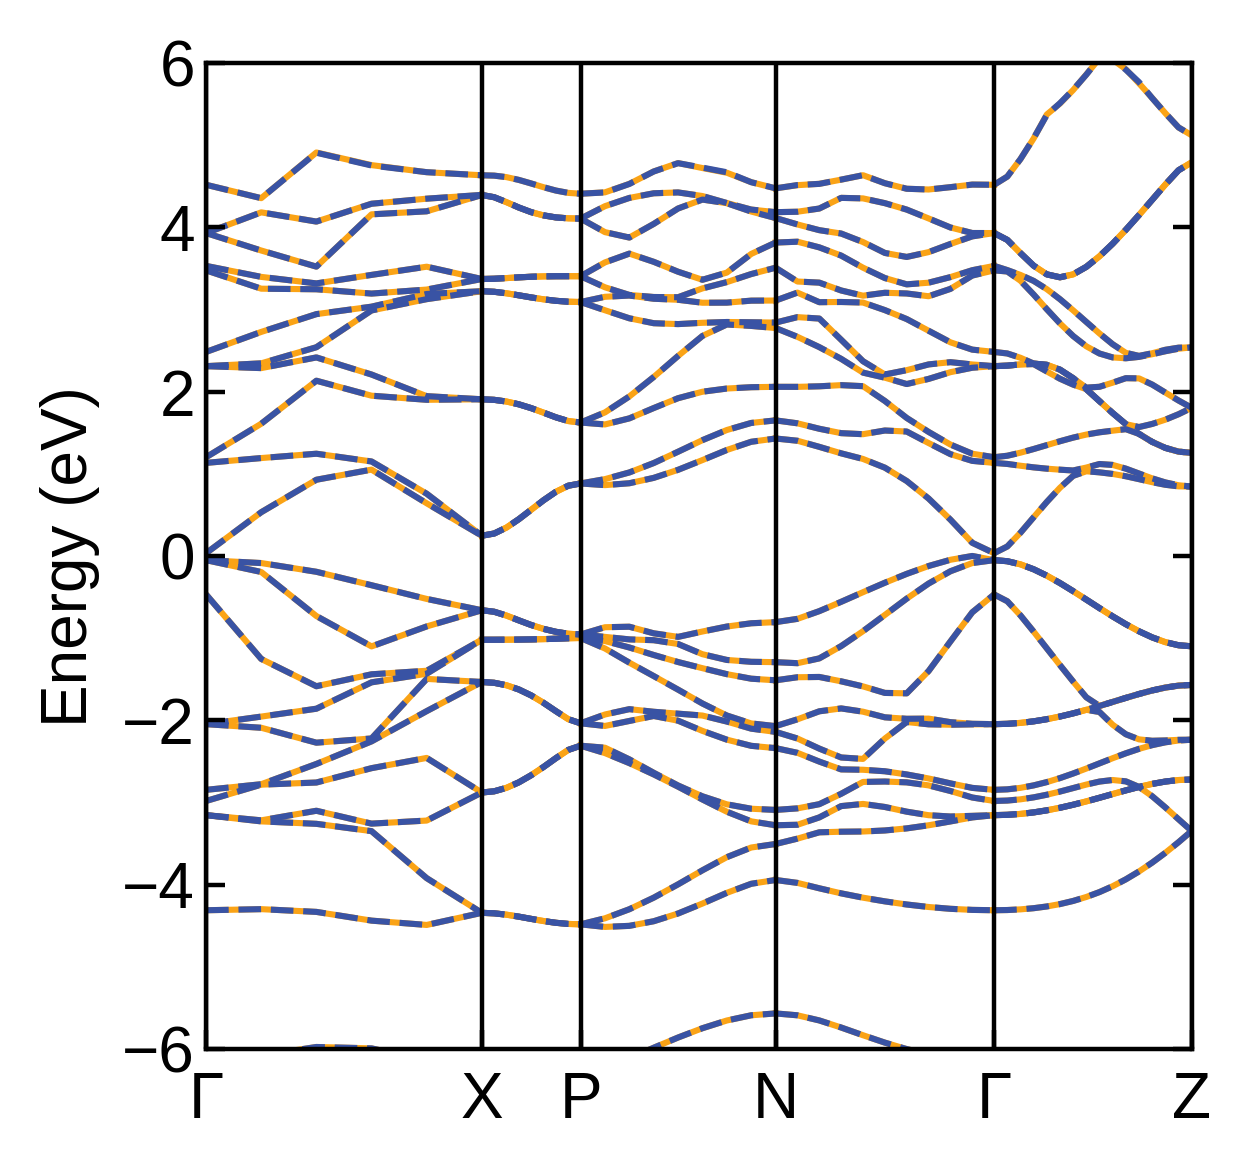

In [36]:
show_bands(node).get_plot()

In [22]:
b.get_vbm()

{'band_index': defaultdict(list, {<Spin.up: 1>: [35], <Spin.down: -1>: [35]}),
 'kpoint_index': [33],
 'kpoint': <pymatgen.electronic_structure.bandstructure.Kpoint at 0x107139395130>,
 'energy': 3.9978,
 'projections': {}}

In [52]:
node.outputs.band_structure.base.attributes.all

{'cell': [[-3.28574128, 3.28574128, 6.48634517],
  [3.28574128, -3.28574128, 6.48634517],
  [3.28574128, 3.28574128, -6.48634517]],
 'pbc1': True,
 'pbc2': True,
 'pbc3': True,
 'units': 'None',
 'efermi': 4.01152507,
 'labels': ['\\Gamma', 'X', 'P', 'N', '\\Gamma', 'Z'],
 'array|bands': [2, 47, 47],
 'fermi_level': 4.01152507,
 'array|kpoints': [47, 3],
 'array|weights': [47],
 'label_numbers': [0, 5, 13, 21, 31, 46],
 'array|occupations': [2, 47, 47]}

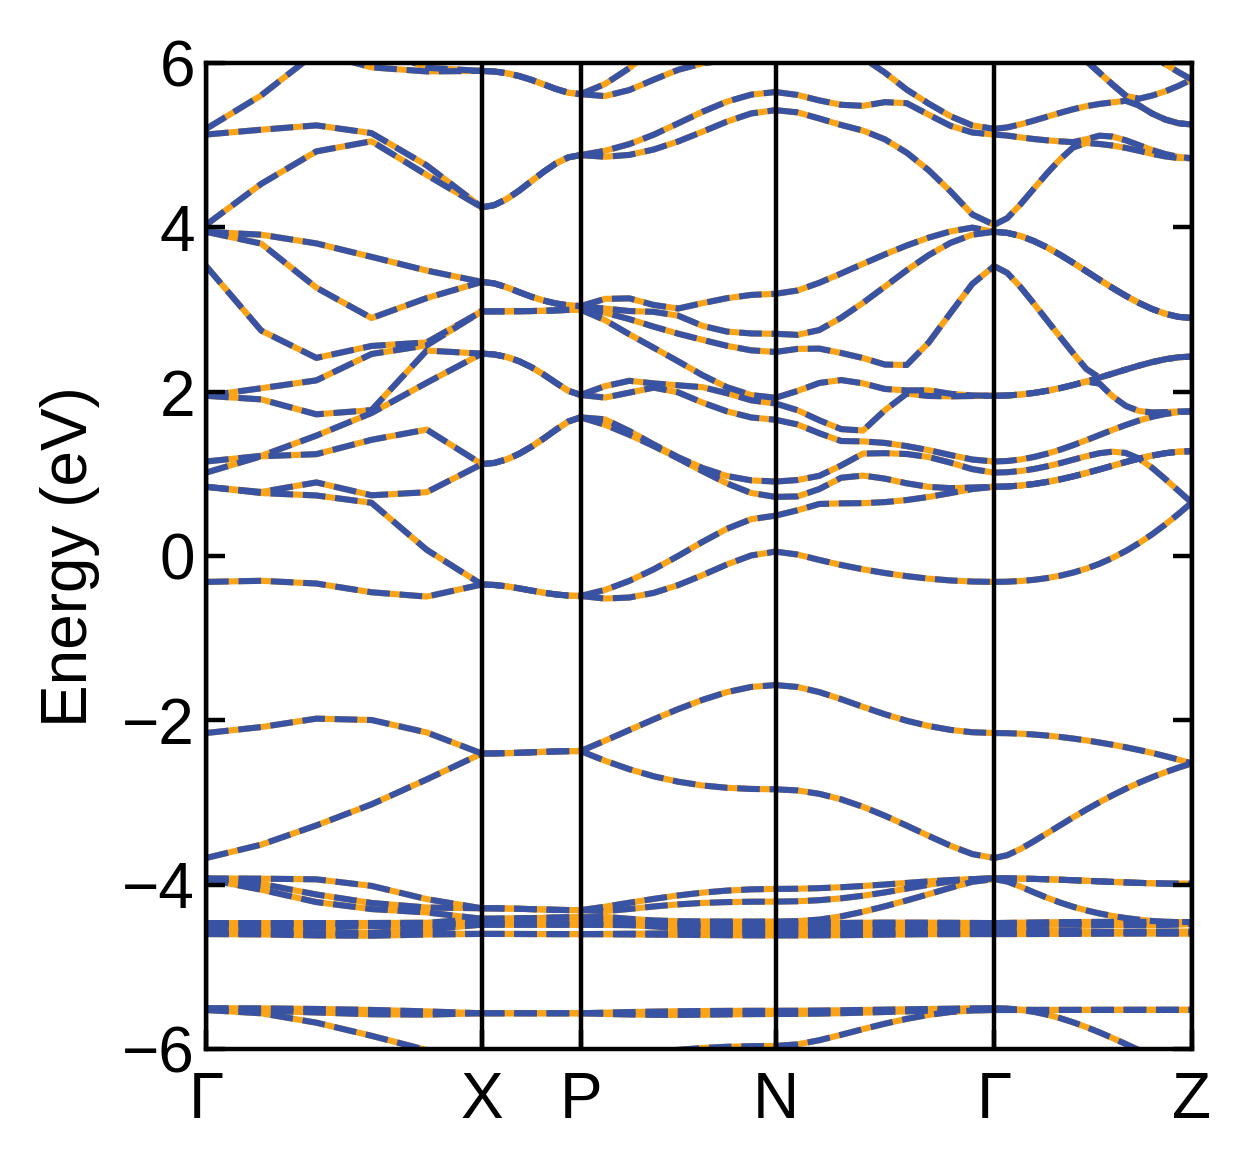

In [53]:
show_bands(node).show()